In [ ]:
# Modifies the previous code with an alternate model.
# XGBRegressor is a powerful machine learning model that can creates many decision trees over
# different combinations of lags, then uses gradient descent to create linear combinations of those trees.
# The output is a complex nonlinear model.

import numpy as np
import pandas as pd
from src import df_sanitizer
import matplotlib.pyplot as plt
import seaborn
import datetime
import statsmodels

df1121 = pd.read_csv(r"Data/Rm1121 - VMA13.csv")
df1121 = df_sanitizer.sanitize_df(df1121)
df1121_sensible_load = 1.08 * df1121["supply air flow"] * (df1121["zone temp"] - df1121["supply air temp"])
df1121_sensible_load.head()

ts
2022-11-04 00:15:00+00:00    3702.334110
2022-11-04 00:30:00+00:00   -7940.642403
2022-11-04 00:45:00+00:00   -8025.785816
2022-11-04 01:00:00+00:00   -7842.391521
2022-11-04 01:15:00+00:00    4625.440292
dtype: float64

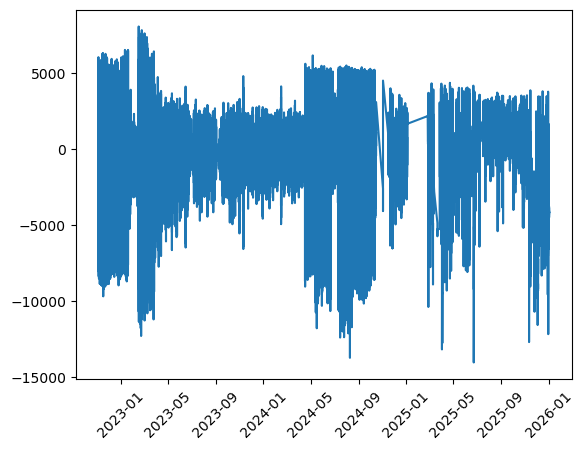

In [ ]:
# Plots the time series starting at November 4, 2022.

plt.plot(df1121_sensible_load)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# An acceptable list of lags. Only the previous 6 values were relevant.
# Additionally, we have 96 data points per day. So, we also include lags from 3, 6, 12, and 24 hours prior.

lags = [1,2,3,4,5,6,12,24,48,96]
windows = [24,96]

In [ ]:
# Records new lists of data points shifted back by the lags.
# This makes it easier to train the model and compare data points to their lagged values.

def create_lags(series, lags):
    df = series.to_frame(name="y").copy()

    for lag in lags:
        df[f"y_lag_{lag}"] = df["y"].shift(lag)

    return df

In [ ]:
# Creates a new dataframe based off of the lags, then drops any rows with missing data (the first 96 rows, since the largest lag is 96).
# df was the original dataframe, but df_model is the new one with the lags.
# We split it into a training set and a test set, with 80% of the data in the training set and 20% in the test set.

df_model = create_lags(df1121_sensible_load, lags)

df_model = df_model.dropna()

train_size = int(0.8 * len(df_model))

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

In [ ]:
# The first 5 rows of the new dataframe with the lags.

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_12,y_lag_24,y_lag_48,y_lag_96
ts,,,,,,,,,,,
2022-11-05 01:30:00+00:00,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,4358.633679,-5972.608825,4336.657611,5484.157389,3702.334110
2022-11-05 01:45:00+00:00,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,-6778.258671,-7508.464264,-2239.736027,-7940.642403
2022-11-05 02:00:00+00:00,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,3833.479490,-5698.044227,-6851.892702,-8025.785816
2022-11-05 02:15:00+00:00,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4356.940530,4333.308224,639.869540,-7842.391521
2022-11-05 02:30:00+00:00,-6937.098958,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,2061.560029,3921.347280,5615.536273,4625.440292


In [ ]:
# Creates new features based on rolling statistics of the previous values.
# This is a common technique in time series analysis to capture trends and patterns in the data.
# We have rolling mean, standard deviation, minimum and maximum.

def create_features(series, lags, windows):

    df = series.to_frame(name="y").copy()

    # Lag features
    for lag in lags:
        df[f"y_lag_{lag}"] = df["y"].shift(lag)

    # Rolling statistics (Average of previous w values)
    for w in windows:
        df[f"roll_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"] = df["y"].shift(1).rolling(w).std()
        df[f"roll_min_{w}"] = df["y"].shift(1).rolling(w).min()
        df[f"roll_max_{w}"] = df["y"].shift(1).rolling(w).max()

    return df

In [ ]:
# Runs the code in the previous window for our specific dataframe.

df_model = create_features(df1121_sensible_load, lags, windows)

df_model = df_model.dropna()

In [ ]:
# Reviews the first 5 rows of the new dataframe with the features.

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_12,y_lag_24,y_lag_48,y_lag_96,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_96,roll_std_96,roll_min_96,roll_max_96
ts,,,,,,,,,,,,,,,,,,,
2022-11-05 01:30:00+00:00,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,4358.633679,-5972.608825,4336.657611,5484.157389,3702.334110,-213.292281,4465.976380,-7508.464264,4559.779060,-938.514467,4853.568592,-8025.785816,6039.91856
2022-11-05 01:45:00+00:00,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,-6778.258671,-7508.464264,-2239.736027,-7940.642403,-609.250202,4466.306298,-7508.464264,4559.779060,-1030.896411,4848.705559,-8025.785816,6039.91856
2022-11-05 02:00:00+00:00,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,3833.479490,-5698.044227,-6851.892702,-8025.785816,-573.057218,4411.146191,-7131.148752,4559.779060,-1017.346309,4830.977652,-8025.785816,6039.91856
2022-11-05 02:15:00+00:00,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4356.940530,4333.308224,639.869540,-7842.391521,-140.547821,4395.656657,-7131.148752,4682.181293,-884.971652,4810.981911,-7990.842439,6039.91856
2022-11-05 02:30:00+00:00,-6937.098958,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,2061.560029,3921.347280,5615.536273,4625.440292,-187.155689,4351.869346,-7131.148752,4682.181293,-769.793413,4774.885170,-7990.842439,6039.91856


In [ ]:
# List of columns

print(df_model.columns)

Index(['y', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_4', 'y_lag_5', 'y_lag_6',
       'y_lag_12', 'y_lag_24', 'y_lag_48', 'y_lag_96', 'roll_mean_24',
       'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_96',
       'roll_std_96', 'roll_min_96', 'roll_max_96'],
      dtype='object')


In [ ]:
# Drops target variable (current sensible load) from the list of features because we want to predict it.

features = df_model.columns.drop("y")

In [14]:
df_model.columns

Index(['y', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_4', 'y_lag_5', 'y_lag_6',
       'y_lag_12', 'y_lag_24', 'y_lag_48', 'y_lag_96', 'roll_mean_24',
       'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_96',
       'roll_std_96', 'roll_min_96', 'roll_max_96'],
      dtype='object')

In [15]:
df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_12,y_lag_24,y_lag_48,y_lag_96,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_96,roll_std_96,roll_min_96,roll_max_96
ts,,,,,,,,,,,,,,,,,,,
2022-11-05 01:30:00+00:00,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,4358.633679,-5972.608825,4336.657611,5484.157389,3702.334110,-213.292281,4465.976380,-7508.464264,4559.779060,-938.514467,4853.568592,-8025.785816,6039.91856
2022-11-05 01:45:00+00:00,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,-6778.258671,-7508.464264,-2239.736027,-7940.642403,-609.250202,4466.306298,-7508.464264,4559.779060,-1030.896411,4848.705559,-8025.785816,6039.91856
2022-11-05 02:00:00+00:00,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,3833.479490,-5698.044227,-6851.892702,-8025.785816,-573.057218,4411.146191,-7131.148752,4559.779060,-1017.346309,4830.977652,-8025.785816,6039.91856
2022-11-05 02:15:00+00:00,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4356.940530,4333.308224,639.869540,-7842.391521,-140.547821,4395.656657,-7131.148752,4682.181293,-884.971652,4810.981911,-7990.842439,6039.91856
2022-11-05 02:30:00+00:00,-6937.098958,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,2061.560029,3921.347280,5615.536273,4625.440292,-187.155689,4351.869346,-7131.148752,4682.181293,-769.793413,4774.885170,-7990.842439,6039.91856


In [ ]:
# The features we will use to predict are all the columns with "lag" in their name, as well as the rolling statistics.
# We want to predict the current sensible load (y) based on the previous values and their rolling statistics.

features = [col for col in df_model.columns if "lag" in col]

X = df_model[features] # What we will use to predict
y = df_model["y"] # What we want to predict

In [ ]:
# Train-test split

split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

ts_test = df_model.iloc[split:]

In [ ]:
# Imports XGBRegressor and fits it to our training data.

from xgboost import XGBRegressor

model = XGBRegressor(
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# Predicts future values

pred = model.predict(X_test)

In [ ]:
# Lists predictions

results = df_model.iloc[split:].copy()
results["prediction"] = pred

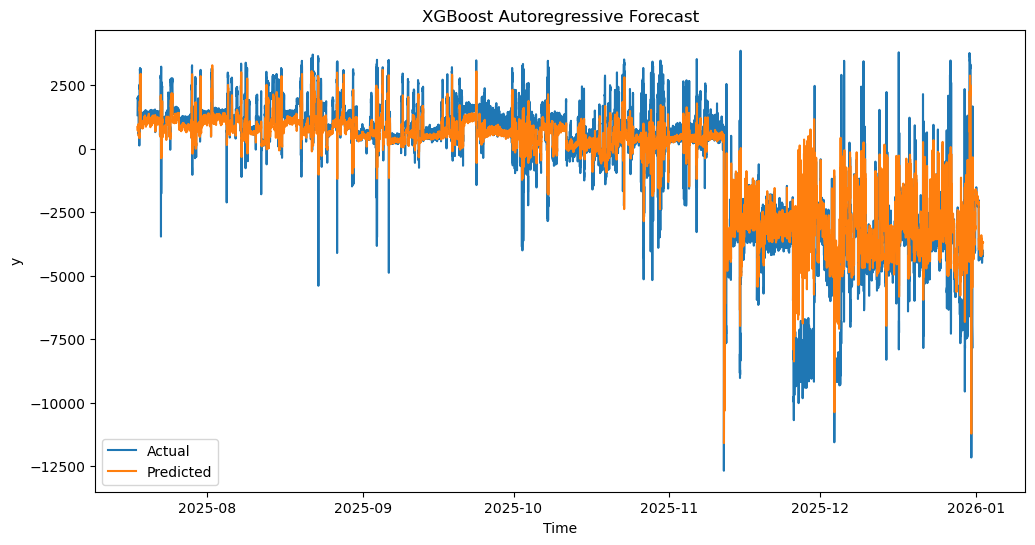

In [ ]:
# Plots predictions vs actual values for the entire test set.

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(results.index, results["y"], label="Actual")
plt.plot(results.index, results["prediction"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

In [22]:
print(X_train.head())

                               y_lag_1      y_lag_2      y_lag_3      y_lag_4  \
ts                                                                              
2022-11-05 01:30:00+00:00   405.535551 -5016.508289 -4116.190480  4559.779060   
2022-11-05 01:45:00+00:00 -5166.332494   405.535551 -5016.508289 -4116.190480   
2022-11-05 02:00:00+00:00 -6639.832653 -5166.332494   405.535551 -5016.508289   
2022-11-05 02:15:00+00:00  4682.181293 -6639.832653 -5166.332494   405.535551   
2022-11-05 02:30:00+00:00  3214.719389  4682.181293 -6639.832653 -5166.332494   

                               y_lag_5      y_lag_6     y_lag_12     y_lag_24  \
ts                                                                              
2022-11-05 01:30:00+00:00  -531.455947  4358.633679 -5972.608825  4336.657611   
2022-11-05 01:45:00+00:00  4559.779060  -531.455947 -6778.258671 -7508.464264   
2022-11-05 02:00:00+00:00 -4116.190480  4559.779060  3833.479490 -5698.044227   
2022-11-05 02:15:00+00:00 -

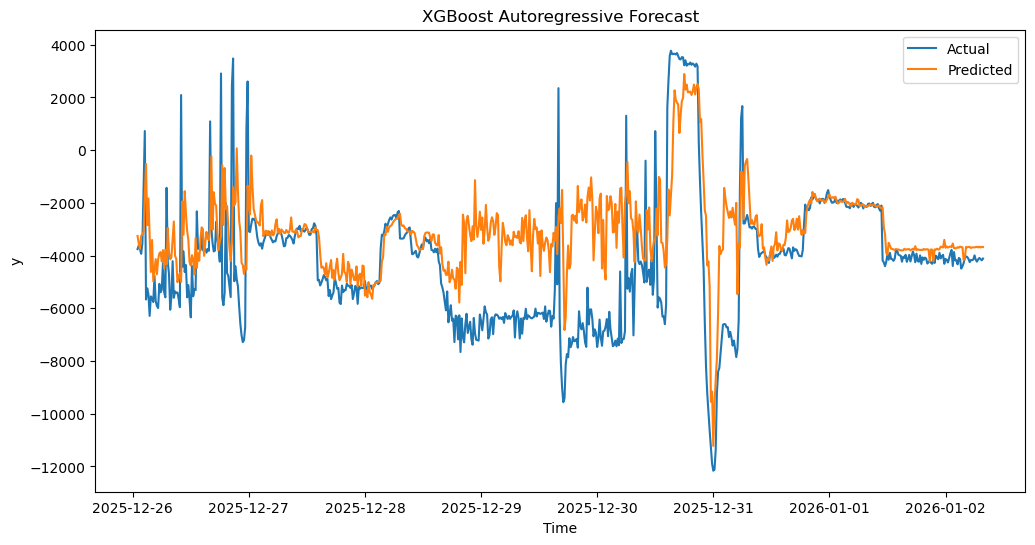

In [ ]:
# Plots predictions vs actual values for the last week of 2025.
# Zooming in on one week allows us to see the predictions more clearly and evaluate the model's performance on a smaller scale.

plt.figure(figsize=(12,6))

plt.plot(results.index[-700:], results["y"][-700:], label="Actual")
plt.plot(results.index[-700:], results["prediction"][-700:], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

In [ ]:
# Checks correlation between predictions and actual values. Obtain 88.9% correlation.

corr = results["y"].corr(results["prediction"])
print("Correlation:", corr)

Correlation: 0.8887975096531175


In [25]:
print('Correlation Over Final 700 Points:', results["y"][-700:].corr(results["prediction"][-700:]))

Correlation Over Final 700 Points: 0.6155301459686237


In [26]:
# Mean Absolute Error is just the average difference between the predicted and actual results
# Root Mean Squared Error is the square root of the average squared difference between the predicted and actual results.
# R² (R-squared) is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

corr = results["y"].corr(results["prediction"])
mae = mean_absolute_error(results["y"], results["prediction"])
rmse = np.sqrt(mean_squared_error(results["y"], results["prediction"]))
r2 = r2_score(results["y"], results["prediction"])

print("Correlation:", corr)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Correlation: 0.8887975096531175
MAE: 755.2051990454881
RMSE: 1355.7969062096436
R²: 0.7566400687068254


In [33]:
# This code looks at the model and determines which lags are the most important.

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
})

importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

    feature  importance
2   y_lag_3    0.198071
0   y_lag_1    0.167348
1   y_lag_2    0.142286
3   y_lag_4    0.141437
4   y_lag_5    0.078062
5   y_lag_6    0.072849
6  y_lag_12    0.058048
8  y_lag_48    0.047980
9  y_lag_96    0.047555
7  y_lag_24    0.046364


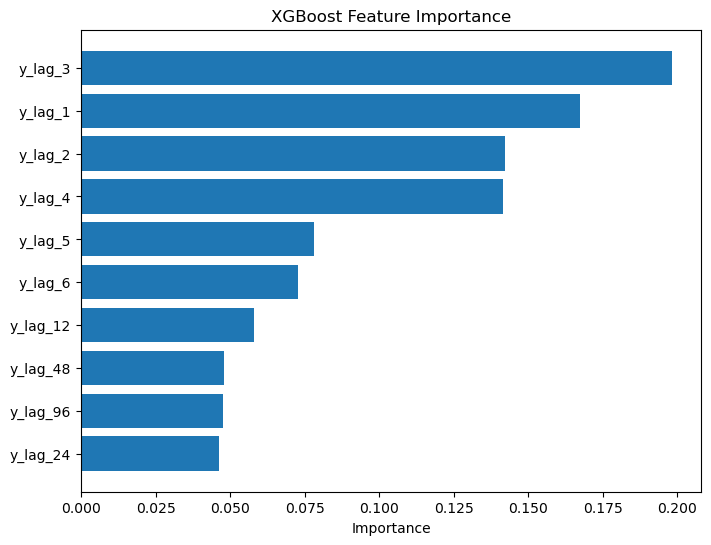

In [ ]:
# Plots features in decreasing order of importance.

plt.figure(figsize=(8,6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")

plt.show()

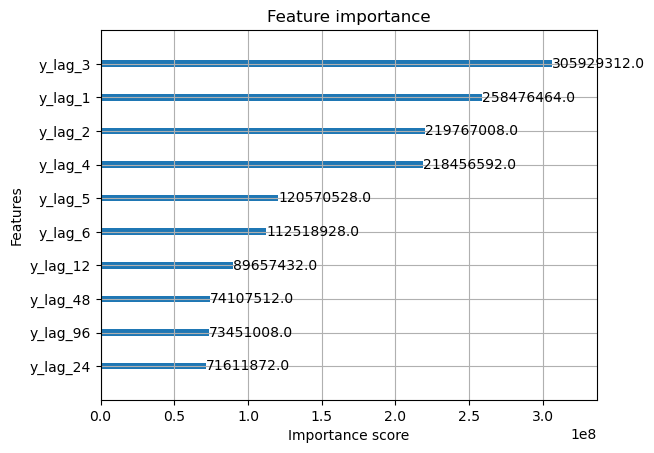

In [35]:
from xgboost import plot_importance

plot_importance(model, importance_type="gain")
plt.show()

In [36]:
# Ranks lag values by importance

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

# Sorts by importance
importance_df = importance_df.sort_values("importance", ascending=False)

# Converts to numerical lag values
importance_df["lag"] = importance_df["feature"].str.extract(r'(\d+)').astype(int)

# Makes into a vector
lag_importance = importance_df.set_index("lag")["importance"].sort_index()

samples_per_day = 96

max_lag = lag_importance.index.max()

heatmap_size = int(np.ceil(max_lag / samples_per_day)) * samples_per_day

heatmap = np.zeros(heatmap_size)

for lag, val in lag_importance.items():
    heatmap[lag-1] = val

heatmap = heatmap.reshape(-1, samples_per_day)

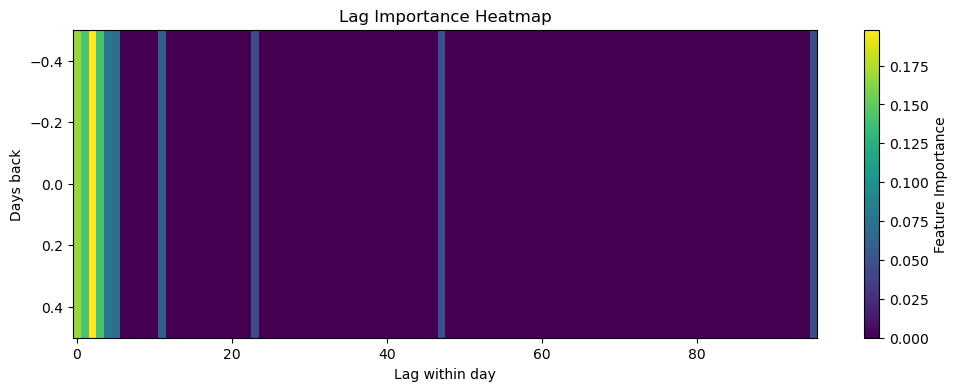

In [ ]:
# Creates heatmap of lag importance, with lags on the y-axis and time within day on the x-axis.

plt.figure(figsize=(12,4))

plt.imshow(heatmap, aspect='auto')

plt.colorbar(label="Feature Importance")

plt.xlabel("Lag within day")
plt.ylabel("Days back")

plt.title("Lag Importance Heatmap")

plt.show()

In [43]:
# This code generates many lag features and lets the model choose the most important ones.

# Records hour and minute as features.

df_model["hour"] = df_model.index.hour
df_model["minute"] = df_model.index.minute
df_model["dayofweek"] = df_model.index.dayofweek

In [44]:
df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_12,y_lag_24,y_lag_48,...,roll_std_24,roll_min_24,roll_max_24,roll_mean_96,roll_std_96,roll_min_96,roll_max_96,hour,minute,dayofweek
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-05 01:30:00+00:00,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,4358.633679,-5972.608825,4336.657611,5484.157389,...,4465.976380,-7508.464264,4559.779060,-938.514467,4853.568592,-8025.785816,6039.91856,1,30,5
2022-11-05 01:45:00+00:00,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,-6778.258671,-7508.464264,-2239.736027,...,4466.306298,-7508.464264,4559.779060,-1030.896411,4848.705559,-8025.785816,6039.91856,1,45,5
2022-11-05 02:00:00+00:00,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,3833.479490,-5698.044227,-6851.892702,...,4411.146191,-7131.148752,4559.779060,-1017.346309,4830.977652,-8025.785816,6039.91856,2,0,5
2022-11-05 02:15:00+00:00,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4356.940530,4333.308224,639.869540,...,4395.656657,-7131.148752,4682.181293,-884.971652,4810.981911,-7990.842439,6039.91856,2,15,5
2022-11-05 02:30:00+00:00,-6937.098958,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,2061.560029,3921.347280,5615.536273,...,4351.869346,-7131.148752,4682.181293,-769.793413,4774.885170,-7990.842439,6039.91856,2,30,5


In [ ]:
# 23:45 and 00:00 appear far apart but are actually close together.
# Cyclic encoding can help the model understand this.
# The same thing occurs with Sunday and Monday. tod = time of day, dow = day of week.

df_model["tod"] = df_model.index.hour * 4 + df_model.index.minute // 15 # Divides by 15 for 15 minute intervals.
df_model["tod_sin"] = np.sin(2 * np.pi * df_model["tod"] / 96)
df_model["tod_cos"] = np.cos(2 * np.pi * df_model["tod"] / 96)
df_model["dow_sin"] = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

In [48]:
df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_12,y_lag_24,y_lag_48,...,roll_min_96,roll_max_96,hour,minute,dayofweek,tod,tod_sin,tod_cos,dow_sin,dow_cos
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-05 01:30:00+00:00,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,4358.633679,-5972.608825,4336.657611,5484.157389,...,-8025.785816,6039.91856,1,30,5,6,0.382683,0.923880,-0.974928,-0.222521
2022-11-05 01:45:00+00:00,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,-531.455947,-6778.258671,-7508.464264,-2239.736027,...,-8025.785816,6039.91856,1,45,5,7,0.442289,0.896873,-0.974928,-0.222521
2022-11-05 02:00:00+00:00,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4559.779060,3833.479490,-5698.044227,-6851.892702,...,-8025.785816,6039.91856,2,0,5,8,0.500000,0.866025,-0.974928,-0.222521
2022-11-05 02:15:00+00:00,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,-4116.190480,4356.940530,4333.308224,639.869540,...,-7990.842439,6039.91856,2,15,5,9,0.555570,0.831470,-0.974928,-0.222521
2022-11-05 02:30:00+00:00,-6937.098958,3214.719389,4682.181293,-6639.832653,-5166.332494,405.535551,-5016.508289,2061.560029,3921.347280,5615.536273,...,-7990.842439,6039.91856,2,30,5,10,0.608761,0.793353,-0.974928,-0.222521


In [ ]:
# One issue with the previous code is that minute, hour, and day of the week do not "roll over".
# So, the model interprets Sunday (dayofweek=6) and Monday (dayofweek=0) as being far apart, when they are actually close together.
# It also has trouble understanding that 23:45 and 00:00 are close together. Cyclic encoding can help the model understand this.

features += ["tod_sin", "tod_cos", "dow_sin", "dow_cos"]
print(features)

['y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_4', 'y_lag_5', 'y_lag_6', 'y_lag_12', 'y_lag_24', 'y_lag_48', 'y_lag_96', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos']


In [51]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

ts_test = df_model.iloc[split:]

model = XGBRegressor(
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


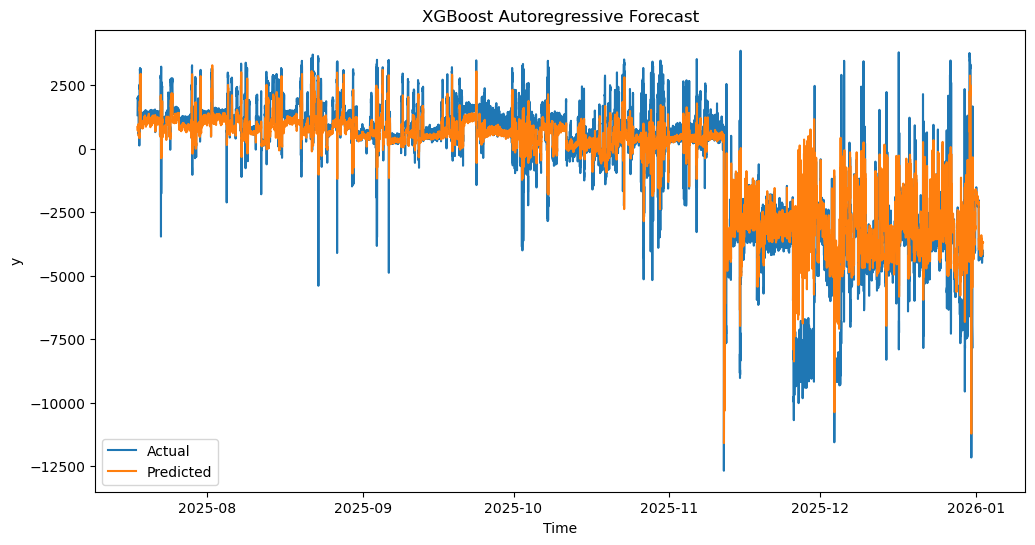

In [52]:
pred = model.predict(X_test)
results = df_model.iloc[split:].copy()
results["prediction"] = pred
plt.figure(figsize=(12,6))

plt.plot(results.index, results["y"], label="Actual")
plt.plot(results.index, results["prediction"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

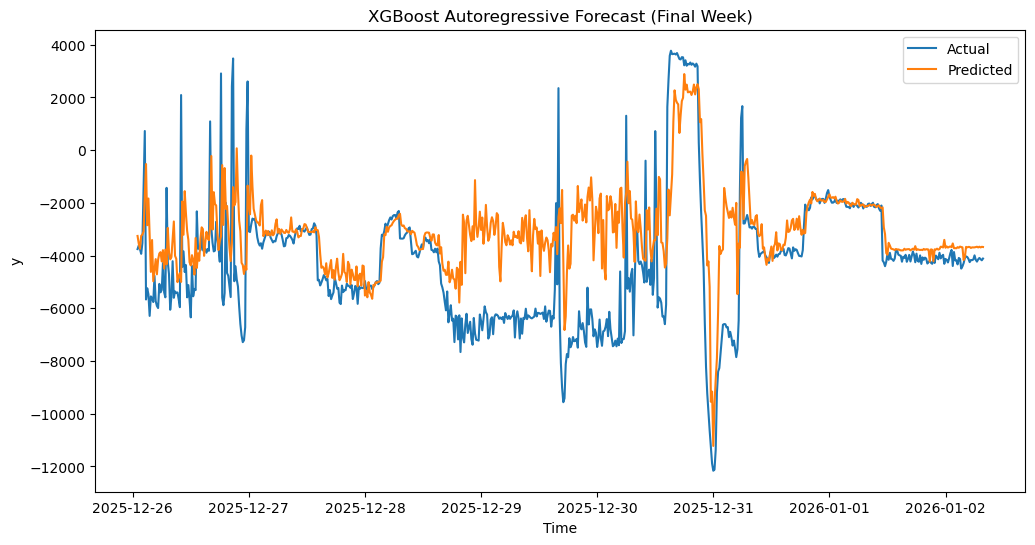

In [53]:
plt.figure(figsize=(12,6))

plt.plot(results.index[-700:], results["y"][-700:], label="Actual")
plt.plot(results.index[-700:], results["prediction"][-700:], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast (Final Week)")

plt.legend()
plt.show()

In [54]:
corr = results["y"].corr(results["prediction"])
mae = mean_absolute_error(results["y"], results["prediction"])
rmse = np.sqrt(mean_squared_error(results["y"], results["prediction"]))
r2 = r2_score(results["y"], results["prediction"])

print("Correlation:", corr)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Correlation: 0.8887975096531175
MAE: 755.2051990454881
RMSE: 1355.7969062096436
R²: 0.7566400687068254


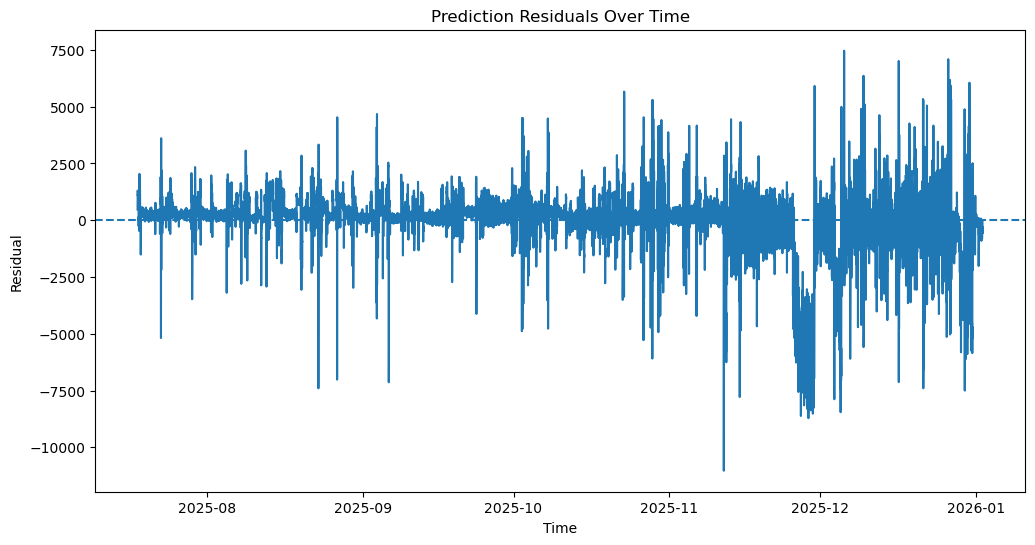

In [56]:
# This code looks for missing daily or weekly patterns.

results["residual"] = results["y"] - results["prediction"]
plt.figure(figsize=(12,6))

plt.plot(results.index, results["residual"])

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Prediction Residuals Over Time")

plt.show()

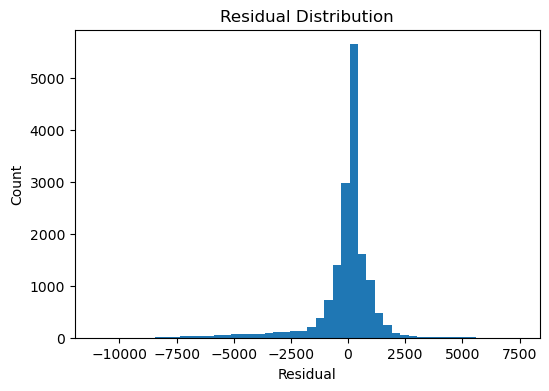

In [57]:
# This actually looks pretty good.
# There are no daily or weekly patterns or extended period of positive or negative values.

plt.figure(figsize=(6,4))

plt.hist(results["residual"], bins=50)

plt.title("Residual Distribution")

plt.xlabel("Residual")
plt.ylabel("Count")

plt.show()

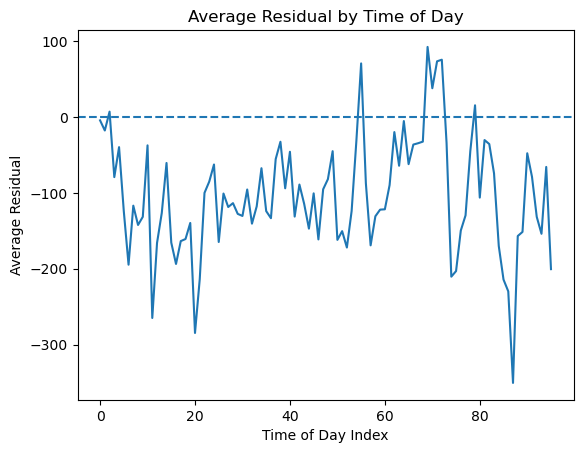

In [58]:
# Again, this is also good as it's unimodal around 0.
# Here are residuals grouped by time of day.

residual_tod = results.groupby("tod")["residual"].mean()

plt.plot(residual_tod)

plt.axhline(0, linestyle="--")

plt.title("Average Residual by Time of Day")

plt.xlabel("Time of Day Index")
plt.ylabel("Average Residual")

plt.show()